# Exercise PT-P2 — Neural Network Training & Testing
### Hands-On Keras Training, Experiment Logging, and Loss Diagnosis
**Author:** Mark Emmanuel P. Sagarino  |  **Course:** ITC-C508

This notebook follows the structure of the provided reference notebook: **CELL 1 (Setup) → CELL 2 (Load Data) →
CELL 3 (Hyperparameters) → CELL 4 (Architecture) → CELL 5 (Optimizer) → CELL 6 (Fit & Evaluate) → CELL 7 (Loss
Curves)**. Each experiment (EXP-01 to EXP-05B) repeats CELLS 3–7 with different settings, and **every code cell is
followed by a line-by-line explanation**.

* **EXP-01 to EXP-05** train on the instructor's `sample_dataset.csv`.
* **EXP-05A / EXP-05B** train on our own `PT-P1_food.csv`.
Upload both CSVs anywhere in your Google Drive before running.

## CELL 1: Setup & Imports

In [ ]:
from google.colab import drive
try:
    drive.mount('/content/drive', force_remount=True)   # refresh so newly uploaded files are seen
except Exception:
    drive.mount('/content/drive')                        # already mounted -> just use it

import pandas as pd, numpy as np, os, glob
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from collections import Counter
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED)
try:
    tf.keras.utils.set_random_seed(SEED); tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# Find a place in Drive to save plots (beside the data)
def find_csv(name):
    hits = sorted(glob.glob(f'/content/drive/MyDrive/**/{name}', recursive=True))
    return hits[0] if hits else None
_anchor = find_csv('sample_dataset.csv') or find_csv('PT-P1_food.csv')
DRIVE = os.path.dirname(_anchor) if _anchor else '/content/drive/MyDrive'
PLOTS_DIR = os.path.join(DRIVE, 'plots'); os.makedirs(PLOTS_DIR, exist_ok=True)
results = []   # collects one row per experiment for the final summary table
print('TensorFlow', tf.__version__, '| output folder:', DRIVE)

Mounted at /content/drive
TensorFlow 2.20.0 | output folder: /content/drive/MyDrive/NN Training/plots


**Line-by-Line Explanation**
1. `drive.mount(...)` connects Google Drive as a folder. We first try `force_remount=True` so newly uploaded files are seen; if Drive is already mounted from an earlier run, Colab raises an error, so the `except` branch simply reuses the existing mount.
2. The `import` block loads Keras (to build/train the model), scikit-learn (split + metrics), pandas/numpy (data), and matplotlib (plots).
3. `SEED = 42` and the determinism settings make every run reproducible — the same code gives the same numbers.
4. `find_csv(...)` searches the whole Drive for a file by name, so the notebook works no matter which folder you uploaded to.
5. `PLOTS_DIR` is created next to the data so every loss-curve image is saved permanently in Drive.

## CELL 2: Load & Preprocess CSV Data (`sample_dataset.csv`)
EXP-01 to EXP-05 use the instructor-provided dataset.

In [ ]:
MAX_LEN = 20            # fixed sequence length (padded / truncated)
MAX_VOCAB_SIZE = 2000   # vocabulary size limit

# --- Load the sample_dataset.csv (found anywhere in Drive) ---
CSV_FILEPATH = find_csv('sample_dataset.csv')
assert CSV_FILEPATH, 'sample_dataset.csv not found in Drive.'
df = pd.read_csv(CSV_FILEPATH)
LABEL_COL = 'category' if 'category' in df.columns else 'label'   # readable class name

# --- Basic tokenizer & vocabulary builder ---
def build_vocab(texts, max_vocab_size):
    words = [w for t in texts for w in str(t).lower().split()]
    most_common = Counter(words).most_common(max_vocab_size - 2)
    vocab = {w: i + 2 for i, (w, _) in enumerate(most_common)}
    vocab['<PAD>'] = 0; vocab['<UNK>'] = 1
    return vocab

def text_to_sequence(text, vocab, max_len):
    seq = [vocab.get(tok, 1) for tok in str(text).lower().split()]
    if len(seq) < max_len:
        seq = seq + [0] * (max_len - len(seq))     # pad with 0
    else:
        seq = seq[:max_len]                         # truncate
    return seq

# --- Encode text and labels ---
classes = sorted(df[LABEL_COL].unique())
label_to_id = {c: i for i, c in enumerate(classes)}
vocab = build_vocab(df['text'].tolist(), MAX_VOCAB_SIZE)
X_data = np.array([text_to_sequence(t, vocab, MAX_LEN) for t in df['text']])
y_data = np.array([label_to_id[l] for l in df[LABEL_COL]])
num_classes = len(classes)

# --- Dataset partitioning (70% Train / 15% Val / 15% Test) ---
def safe_split(X, y, ts):
    try:
        return train_test_split(X, y, test_size=ts, random_state=SEED, stratify=y)
    except ValueError:                              # too few per class to stratify
        return train_test_split(X, y, test_size=ts, random_state=SEED)
X_train, X_temp, y_train, y_temp = safe_split(X_data, y_data, 0.30)
X_val,  X_test, y_val,  y_test  = safe_split(X_temp, y_temp, 0.50)
print('classes:', classes, '| vocab:', len(vocab))
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

classes: ['Negative Feedback', 'Positive Feedback', 'Urgent Support'] | vocab: 149
Train: (10, 20) | Val: (2, 20) | Test: (3, 20)


**Line-by-Line Explanation**
1. `MAX_LEN` / `MAX_VOCAB_SIZE` set the fixed input length and the vocabulary cap.
2. `CSV_FILEPATH = find_csv('sample_dataset.csv')` locates the file; `pd.read_csv` loads it into a table.
3. `build_vocab` counts words and gives each a number, reserving 0 for padding (`<PAD>`) and 1 for unknown words (`<UNK>`).
4. `text_to_sequence` converts a sentence to those numbers and pads/truncates it to `MAX_LEN`.
5. `X_data` are the encoded sentences; `y_data` are the integer class labels; `num_classes` is 3.
6. `safe_split` performs the 70/15/15 split, falling back to a non-stratified split when a class is too small (the 15-row sample set).

## CELL 3: Hyperparameter Configuration — EXP-01-KERAS-BASELINE
The default baseline configuration on `sample_dataset.csv` — our reference point.

In [ ]:
CONFIG = {
    "run_id": "EXP-01-KERAS-BASELINE",
    "embed_dim": 32,
    "hidden_dim": 64,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.1
}

**Line-by-Line Explanation**
1. `run_id` — the label `EXP-01-KERAS-BASELINE`, used in printouts and the saved plot filename.
2. `embed_dim` = 32 — size of each word vector (**Pillar 1: Architecture**).
3. `hidden_dim` = 64 — neurons in the hidden Dense layer (**Pillar 1: Architecture**).
4. `learning_rate` = 0.005 — how big each weight update is (**Pillar 2: Optimization**).
5. `batch_size` = 32 / `epochs` = 15 — batch size and number of passes (**Pillar 2**).
6. `dropout_rate` = 0.1 — fraction of neurons switched off during training (**Pillar 3: Regularization**).

## CELL 4: Keras Sequential Architecture — EXP-01-KERAS-BASELINE

In [ ]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,), dtype='int32'))
model.add(Embedding(input_dim=len(vocab), output_dim=CONFIG["embed_dim"], mask_zero=True))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 32)         │         4,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,075 (27.64 KB)

 Trainable params: 7,075 (27.64 KB)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**
1. `Sequential()` — a straight stack of layers.
2. `Input(shape=(MAX_LEN,))` — fixes the input to `MAX_LEN` token IDs (keeps Keras 3 happy and lets `summary()` work).
3. `Embedding(...)` — turns each token ID into a trainable `embed_dim`-length vector; `mask_zero=True` ignores padding.
4. `GlobalAveragePooling1D()` — averages the word vectors into one sentence vector (this + Embedding = feature extraction).
5. `Dense(hidden_dim, 'relu')` — the hidden classification layer.
6. `Dropout(dropout_rate)` — regularization to fight overfitting.
7. `Dense(num_classes, 'softmax')` — outputs a probability for each class.

## CELL 5: Optimizer & Compilation — EXP-01-KERAS-BASELINE

In [ ]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

**Line-by-Line Explanation**
1. The `if/else` picks the optimizer engine — **Adam** (adaptive) or **SGD** — using the configured learning rate.
2. `model.compile(...)` attaches the **loss function** (`sparse_categorical_crossentropy`, for integer labels), the optimizer, and the metric (accuracy). This prepares the model for training.

## CELL 6: The Operational Loop (Fit & Evaluate) — EXP-01-KERAS-BASELINE

In [ ]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Final validation metrics for the experiment log
val_preds = np.argmax(model.predict(X_val), axis=1)
val_f1 = f1_score(y_val, val_preds, average='weighted', zero_division=0)
val_acc = accuracy_score(y_val, val_preds)
val_loss = history.history['val_loss'][-1]
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | "
      f"Dropout: {CONFIG['dropout_rate']} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Save this run into the results list for the final summary table
results = [r for r in results if r['Run ID'] != CONFIG['run_id']]   # avoid duplicates on re-run
results.append({
    'Run ID': CONFIG['run_id'], 'Dataset': os.path.basename(CSV_FILEPATH),
    'Embed': CONFIG['embed_dim'], 'Hidden': CONFIG['hidden_dim'], 'LR': CONFIG['learning_rate'],
    'Dropout': CONFIG['dropout_rate'], 'Batch': CONFIG['batch_size'],
    'Epochs Run': len(history.history['loss']), 'Val Size': int(len(y_val)),
    'Train Loss': round(float(history.history['loss'][-1]), 4),
    'Val Loss': round(float(val_loss), 4),
    'Train Acc': round(float(history.history['accuracy'][-1]), 4),
    'Val Acc': round(float(val_acc), 4), 'Val F1': round(float(val_f1), 4),
})

--- Starting Training Run: EXP-01-KERAS-BASELINE ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6000 - loss: 1.0964 - val_accuracy: 0.0000e+00 - val_loss: 1.1109
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6000 - loss: 1.0814 - val_accuracy: 0.0000e+00 - val_loss: 1.1237
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4000 - loss: 1.0659 - val_accuracy: 0.0000e+00 - val_loss: 1.1390
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4000 - loss: 1.0529 - val_accuracy: 0.0000e+00 - val_loss: 1.1516
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5000 - loss: 1.0239 - val_accuracy: 0.0000e+00 - val_loss: 1.1637
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7000 - loss: 1.0040 - val_accuracy: 0.0000e+00 - val_loss: 1.1739
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9000 - loss: 0.9654 - val_accuracy: 0.0000e+00 - val_loss: 1.1834
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/st

**Line-by-Line Explanation**
1. `model.fit(...)` is the training loop — for every batch of every epoch Keras runs the **Forward Pass → Loss Calculation → Backward Pass (backpropagation) → Weight Update**.
2. `validation_data=(X_val, y_val)` evaluates the model on unseen data after each epoch so we can watch for overfitting.
3. `np.argmax(model.predict(X_val), axis=1)` turns the softmax probabilities into predicted class numbers.
4. `val_f1`, `val_acc`, `val_loss` are the final numbers we record for this run in the experiment log.

## CELL 7: Generate Loss Curves Chart — EXP-01-KERAS-BASELINE

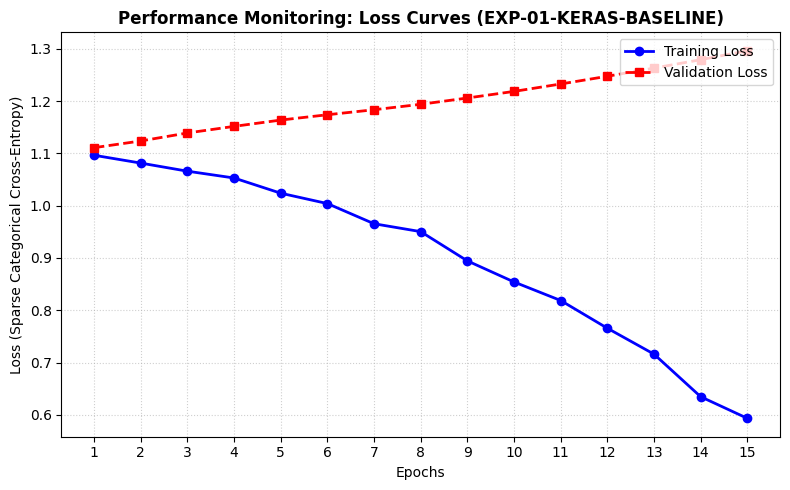

In [ ]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')
plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10); plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range); plt.grid(True, linestyle=':', alpha=0.6); plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CONFIG["run_id"]}.png'), dpi=120)
plt.show()

**Line-by-Line Explanation**
1. `train_losses` / `val_losses` are pulled from the training `history` object.
2. The two `plt.plot` calls draw the training loss (blue) and validation loss (red dashed) against the epoch number.
3. Reading the two curves is the diagnosis: **flat and high** = underfitting; **train drops but val rises** = overfitting; **both fall together** = a good fit.
4. `plt.savefig(...)` stores the chart in the Drive `plots` folder so it can be embedded in the IEEE report.

## CELL 3: Hyperparameter Configuration — EXP-02-UNDERFIT
A **tiny learning rate + low capacity** to deliberately induce **underfitting**.

In [ ]:
CONFIG = {
    "run_id": "EXP-02-UNDERFIT",
    "embed_dim": 32,
    "hidden_dim": 16,
    "learning_rate": 0.0001,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.0
}

**Line-by-Line Explanation**
1. `run_id` — the label `EXP-02-UNDERFIT`, used in printouts and the saved plot filename.
2. `embed_dim` = 32 — size of each word vector (**Pillar 1: Architecture**).
3. `hidden_dim` = 16 — neurons in the hidden Dense layer (**Pillar 1: Architecture**).
4. `learning_rate` = 0.0001 — how big each weight update is (**Pillar 2: Optimization**).
5. `batch_size` = 32 / `epochs` = 15 — batch size and number of passes (**Pillar 2**).
6. `dropout_rate` = 0.0 — fraction of neurons switched off during training (**Pillar 3: Regularization**).

## CELL 4: Keras Sequential Architecture — EXP-02-UNDERFIT

In [ ]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,), dtype='int32'))
model.add(Embedding(input_dim=len(vocab), output_dim=CONFIG["embed_dim"], mask_zero=True))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 20, 32)         │         4,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,347 (20.89 KB)

 Trainable params: 5,347 (20.89 KB)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**
1. `Sequential()` — a straight stack of layers.
2. `Input(shape=(MAX_LEN,))` — fixes the input to `MAX_LEN` token IDs (keeps Keras 3 happy and lets `summary()` work).
3. `Embedding(...)` — turns each token ID into a trainable `embed_dim`-length vector; `mask_zero=True` ignores padding.
4. `GlobalAveragePooling1D()` — averages the word vectors into one sentence vector (this + Embedding = feature extraction).
5. `Dense(hidden_dim, 'relu')` — the hidden classification layer.
6. `Dropout(dropout_rate)` — regularization to fight overfitting.
7. `Dense(num_classes, 'softmax')` — outputs a probability for each class.

## CELL 5: Optimizer & Compilation — EXP-02-UNDERFIT

In [ ]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

**Line-by-Line Explanation**
1. The `if/else` picks the optimizer engine — **Adam** (adaptive) or **SGD** — using the configured learning rate.
2. `model.compile(...)` attaches the **loss function** (`sparse_categorical_crossentropy`, for integer labels), the optimizer, and the metric (accuracy). This prepares the model for training.

## CELL 6: The Operational Loop (Fit & Evaluate) — EXP-02-UNDERFIT

In [ ]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Final validation metrics for the experiment log
val_preds = np.argmax(model.predict(X_val), axis=1)
val_f1 = f1_score(y_val, val_preds, average='weighted', zero_division=0)
val_acc = accuracy_score(y_val, val_preds)
val_loss = history.history['val_loss'][-1]
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | "
      f"Dropout: {CONFIG['dropout_rate']} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Save this run into the results list for the final summary table
results = [r for r in results if r['Run ID'] != CONFIG['run_id']]   # avoid duplicates on re-run
results.append({
    'Run ID': CONFIG['run_id'], 'Dataset': os.path.basename(CSV_FILEPATH),
    'Embed': CONFIG['embed_dim'], 'Hidden': CONFIG['hidden_dim'], 'LR': CONFIG['learning_rate'],
    'Dropout': CONFIG['dropout_rate'], 'Batch': CONFIG['batch_size'],
    'Epochs Run': len(history.history['loss']), 'Val Size': int(len(y_val)),
    'Train Loss': round(float(history.history['loss'][-1]), 4),
    'Val Loss': round(float(val_loss), 4),
    'Train Acc': round(float(history.history['accuracy'][-1]), 4),
    'Val Acc': round(float(val_acc), 4), 'Val F1': round(float(val_f1), 4),
})

--- Starting Training Run: EXP-02-UNDERFIT ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 941ms/step - accuracy: 0.4000 - loss: 1.0959 - val_accuracy: 1.0000 - val_loss: 1.0941
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4000 - loss: 1.0956 - val_accuracy: 1.0000 - val_loss: 1.0942
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.4000 - loss: 1.0952 - val_accuracy: 1.0000 - val_loss: 1.0942
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.4000 - loss: 1.0948 - val_accuracy: 1.0000 - val_loss: 1.0943
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4000 - loss: 1.0944 - val_accuracy: 1.0000 - val_loss: 1.0944
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.5000 - loss: 1.0940 - val_accuracy: 1.0000 - val_loss: 1.0944
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.5000 - loss: 1.0937 - val_accuracy: 1.0000 - val_loss: 1.0945
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5000 - loss: 

**Line-by-Line Explanation**
1. `model.fit(...)` is the training loop — for every batch of every epoch Keras runs the **Forward Pass → Loss Calculation → Backward Pass (backpropagation) → Weight Update**.
2. `validation_data=(X_val, y_val)` evaluates the model on unseen data after each epoch so we can watch for overfitting.
3. `np.argmax(model.predict(X_val), axis=1)` turns the softmax probabilities into predicted class numbers.
4. `val_f1`, `val_acc`, `val_loss` are the final numbers we record for this run in the experiment log.

## CELL 7: Generate Loss Curves Chart — EXP-02-UNDERFIT

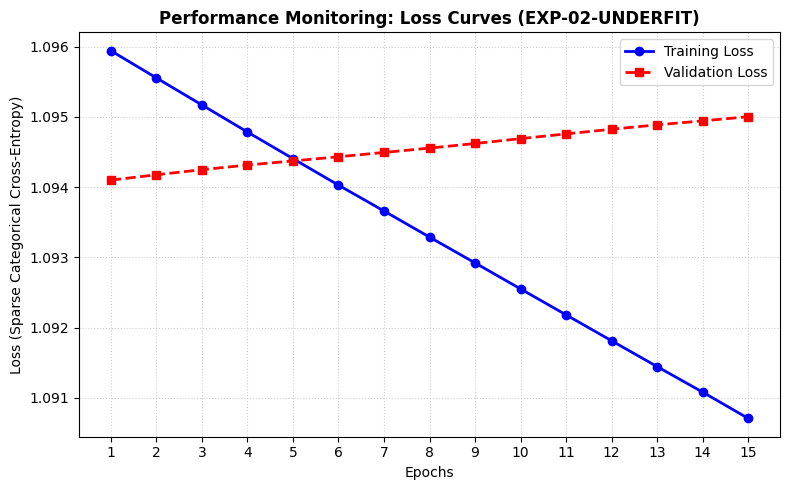

In [ ]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')
plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10); plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range); plt.grid(True, linestyle=':', alpha=0.6); plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CONFIG["run_id"]}.png'), dpi=120)
plt.show()

**Line-by-Line Explanation**
1. `train_losses` / `val_losses` are pulled from the training `history` object.
2. The two `plt.plot` calls draw the training loss (blue) and validation loss (red dashed) against the epoch number.
3. Reading the two curves is the diagnosis: **flat and high** = underfitting; **train drops but val rises** = overfitting; **both fall together** = a good fit.
4. `plt.savefig(...)` stores the chart in the Drive `plots` folder so it can be embedded in the IEEE report.

## CELL 3: Hyperparameter Configuration — EXP-03-OVERFIT
**High capacity + large learning rate + no dropout** to deliberately induce **overfitting**.

In [ ]:
CONFIG = {
    "run_id": "EXP-03-OVERFIT",
    "embed_dim": 32,
    "hidden_dim": 256,
    "learning_rate": 0.05,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.0
}

**Line-by-Line Explanation**
1. `run_id` — the label `EXP-03-OVERFIT`, used in printouts and the saved plot filename.
2. `embed_dim` = 32 — size of each word vector (**Pillar 1: Architecture**).
3. `hidden_dim` = 256 — neurons in the hidden Dense layer (**Pillar 1: Architecture**).
4. `learning_rate` = 0.05 — how big each weight update is (**Pillar 2: Optimization**).
5. `batch_size` = 32 / `epochs` = 15 — batch size and number of passes (**Pillar 2**).
6. `dropout_rate` = 0.0 — fraction of neurons switched off during training (**Pillar 3: Regularization**).

## CELL 4: Keras Sequential Architecture — EXP-03-OVERFIT

In [ ]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,), dtype='int32'))
model.add(Embedding(input_dim=len(vocab), output_dim=CONFIG["embed_dim"], mask_zero=True))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 20, 32)         │         4,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,987 (54.64 KB)

 Trainable params: 13,987 (54.64 KB)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**
1. `Sequential()` — a straight stack of layers.
2. `Input(shape=(MAX_LEN,))` — fixes the input to `MAX_LEN` token IDs (keeps Keras 3 happy and lets `summary()` work).
3. `Embedding(...)` — turns each token ID into a trainable `embed_dim`-length vector; `mask_zero=True` ignores padding.
4. `GlobalAveragePooling1D()` — averages the word vectors into one sentence vector (this + Embedding = feature extraction).
5. `Dense(hidden_dim, 'relu')` — the hidden classification layer.
6. `Dropout(dropout_rate)` — regularization to fight overfitting.
7. `Dense(num_classes, 'softmax')` — outputs a probability for each class.

## CELL 5: Optimizer & Compilation — EXP-03-OVERFIT

In [ ]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

**Line-by-Line Explanation**
1. The `if/else` picks the optimizer engine — **Adam** (adaptive) or **SGD** — using the configured learning rate.
2. `model.compile(...)` attaches the **loss function** (`sparse_categorical_crossentropy`, for integer labels), the optimizer, and the metric (accuracy). This prepares the model for training.

## CELL 6: The Operational Loop (Fit & Evaluate) — EXP-03-OVERFIT

In [ ]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Final validation metrics for the experiment log
val_preds = np.argmax(model.predict(X_val), axis=1)
val_f1 = f1_score(y_val, val_preds, average='weighted', zero_division=0)
val_acc = accuracy_score(y_val, val_preds)
val_loss = history.history['val_loss'][-1]
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | "
      f"Dropout: {CONFIG['dropout_rate']} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Save this run into the results list for the final summary table
results = [r for r in results if r['Run ID'] != CONFIG['run_id']]   # avoid duplicates on re-run
results.append({
    'Run ID': CONFIG['run_id'], 'Dataset': os.path.basename(CSV_FILEPATH),
    'Embed': CONFIG['embed_dim'], 'Hidden': CONFIG['hidden_dim'], 'LR': CONFIG['learning_rate'],
    'Dropout': CONFIG['dropout_rate'], 'Batch': CONFIG['batch_size'],
    'Epochs Run': len(history.history['loss']), 'Val Size': int(len(y_val)),
    'Train Loss': round(float(history.history['loss'][-1]), 4),
    'Val Loss': round(float(val_loss), 4),
    'Train Acc': round(float(history.history['accuracy'][-1]), 4),
    'Val Acc': round(float(val_acc), 4), 'Val F1': round(float(val_f1), 4),
})

--- Starting Training Run: EXP-03-OVERFIT ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 970ms/step - accuracy: 0.4000 - loss: 1.0991 - val_accuracy: 0.0000e+00 - val_loss: 1.2748
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.4000 - loss: 1.0198 - val_accuracy: 0.0000e+00 - val_loss: 1.2281
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.4883 - val_accuracy: 0.0000e+00 - val_loss: 1.3476
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 1.0000 - loss: 0.0844 - val_accuracy: 0.0000e+00 - val_loss: 1.7782
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.0000e+00 - val_loss: 2.5604
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 3.8646e-05 - val_accuracy: 0.0000e+00 - val_loss: 3.6275
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 4.8876e-07 - val_accuracy: 0.0000e+00 - val_loss: 4.8644
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59m

**Line-by-Line Explanation**
1. `model.fit(...)` is the training loop — for every batch of every epoch Keras runs the **Forward Pass → Loss Calculation → Backward Pass (backpropagation) → Weight Update**.
2. `validation_data=(X_val, y_val)` evaluates the model on unseen data after each epoch so we can watch for overfitting.
3. `np.argmax(model.predict(X_val), axis=1)` turns the softmax probabilities into predicted class numbers.
4. `val_f1`, `val_acc`, `val_loss` are the final numbers we record for this run in the experiment log.

## CELL 7: Generate Loss Curves Chart — EXP-03-OVERFIT

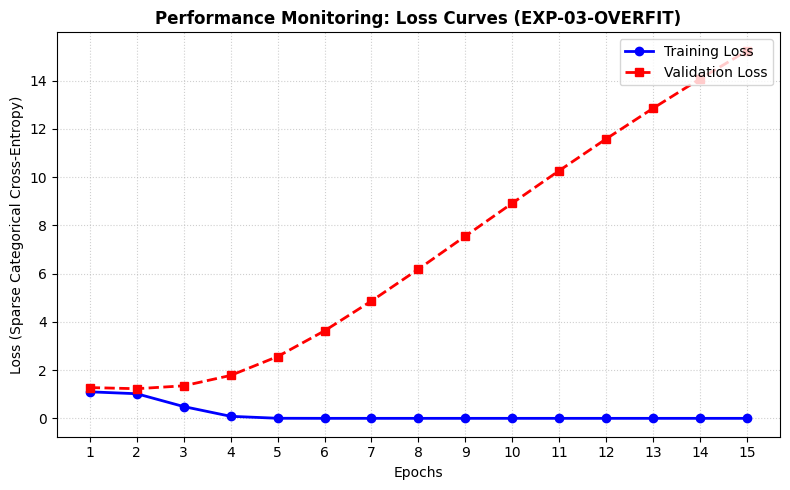

In [ ]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')
plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10); plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range); plt.grid(True, linestyle=':', alpha=0.6); plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CONFIG["run_id"]}.png'), dpi=120)
plt.show()

**Line-by-Line Explanation**
1. `train_losses` / `val_losses` are pulled from the training `history` object.
2. The two `plt.plot` calls draw the training loss (blue) and validation loss (red dashed) against the epoch number.
3. Reading the two curves is the diagnosis: **flat and high** = underfitting; **train drops but val rises** = overfitting; **both fall together** = a good fit.
4. `plt.savefig(...)` stores the chart in the Drive `plots` folder so it can be embedded in the IEEE report.

## CELL 3: Hyperparameter Configuration — EXP-04-REGULARIZED
The same high capacity **with dropout 0.4** to show regularization fixing the overfitting from EXP-03.

In [ ]:
CONFIG = {
    "run_id": "EXP-04-REGULARIZED",
    "embed_dim": 32,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 32,
    "epochs": 15,
    "optimizer_type": "Adam",
    "dropout_rate": 0.4
}

**Line-by-Line Explanation**
1. `run_id` — the label `EXP-04-REGULARIZED`, used in printouts and the saved plot filename.
2. `embed_dim` = 32 — size of each word vector (**Pillar 1: Architecture**).
3. `hidden_dim` = 128 — neurons in the hidden Dense layer (**Pillar 1: Architecture**).
4. `learning_rate` = 0.005 — how big each weight update is (**Pillar 2: Optimization**).
5. `batch_size` = 32 / `epochs` = 15 — batch size and number of passes (**Pillar 2**).
6. `dropout_rate` = 0.4 — fraction of neurons switched off during training (**Pillar 3: Regularization**).

## CELL 4: Keras Sequential Architecture — EXP-04-REGULARIZED

In [ ]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,), dtype='int32'))
model.add(Embedding(input_dim=len(vocab), output_dim=CONFIG["embed_dim"], mask_zero=True))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 20, 32)         │         4,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,379 (36.64 KB)

 Trainable params: 9,379 (36.64 KB)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**
1. `Sequential()` — a straight stack of layers.
2. `Input(shape=(MAX_LEN,))` — fixes the input to `MAX_LEN` token IDs (keeps Keras 3 happy and lets `summary()` work).
3. `Embedding(...)` — turns each token ID into a trainable `embed_dim`-length vector; `mask_zero=True` ignores padding.
4. `GlobalAveragePooling1D()` — averages the word vectors into one sentence vector (this + Embedding = feature extraction).
5. `Dense(hidden_dim, 'relu')` — the hidden classification layer.
6. `Dropout(dropout_rate)` — regularization to fight overfitting.
7. `Dense(num_classes, 'softmax')` — outputs a probability for each class.

## CELL 5: Optimizer & Compilation — EXP-04-REGULARIZED

In [ ]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

**Line-by-Line Explanation**
1. The `if/else` picks the optimizer engine — **Adam** (adaptive) or **SGD** — using the configured learning rate.
2. `model.compile(...)` attaches the **loss function** (`sparse_categorical_crossentropy`, for integer labels), the optimizer, and the metric (accuracy). This prepares the model for training.

## CELL 6: The Operational Loop (Fit & Evaluate) — EXP-04-REGULARIZED

In [ ]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    verbose=1
)

# Final validation metrics for the experiment log
val_preds = np.argmax(model.predict(X_val), axis=1)
val_f1 = f1_score(y_val, val_preds, average='weighted', zero_division=0)
val_acc = accuracy_score(y_val, val_preds)
val_loss = history.history['val_loss'][-1]
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | "
      f"Dropout: {CONFIG['dropout_rate']} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Save this run into the results list for the final summary table
results = [r for r in results if r['Run ID'] != CONFIG['run_id']]   # avoid duplicates on re-run
results.append({
    'Run ID': CONFIG['run_id'], 'Dataset': os.path.basename(CSV_FILEPATH),
    'Embed': CONFIG['embed_dim'], 'Hidden': CONFIG['hidden_dim'], 'LR': CONFIG['learning_rate'],
    'Dropout': CONFIG['dropout_rate'], 'Batch': CONFIG['batch_size'],
    'Epochs Run': len(history.history['loss']), 'Val Size': int(len(y_val)),
    'Train Loss': round(float(history.history['loss'][-1]), 4),
    'Val Loss': round(float(val_loss), 4),
    'Train Acc': round(float(history.history['accuracy'][-1]), 4),
    'Val Acc': round(float(val_acc), 4), 'Val F1': round(float(val_f1), 4),
})

--- Starting Training Run: EXP-04-REGULARIZED ---
Epoch 1/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3000 - loss: 1.0995 - val_accuracy: 0.0000e+00 - val_loss: 1.1025
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5000 - loss: 1.0887 - val_accuracy: 0.0000e+00 - val_loss: 1.1072
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4000 - loss: 1.0785 - val_accuracy: 0.0000e+00 - val_loss: 1.1133
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5000 - loss: 1.0634 - val_accuracy: 0.0000e+00 - val_loss: 1.1201
Epoch 5/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.4000 - loss: 1.0458 - val_accuracy: 0.0000e+00 - val_loss: 1.1278
Epoch 6/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6000 - loss: 1.0261 - val_accuracy: 0.0000e+00 - val_loss: 1.1362
Epoch 7/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.6000 - loss: 1.0045 - val_accuracy: 0.0000e+00 - val_loss: 1.1462
Epoch 8/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

**Line-by-Line Explanation**
1. `model.fit(...)` is the training loop — for every batch of every epoch Keras runs the **Forward Pass → Loss Calculation → Backward Pass (backpropagation) → Weight Update**.
2. `validation_data=(X_val, y_val)` evaluates the model on unseen data after each epoch so we can watch for overfitting.
3. `np.argmax(model.predict(X_val), axis=1)` turns the softmax probabilities into predicted class numbers.
4. `val_f1`, `val_acc`, `val_loss` are the final numbers we record for this run in the experiment log.

## CELL 7: Generate Loss Curves Chart — EXP-04-REGULARIZED

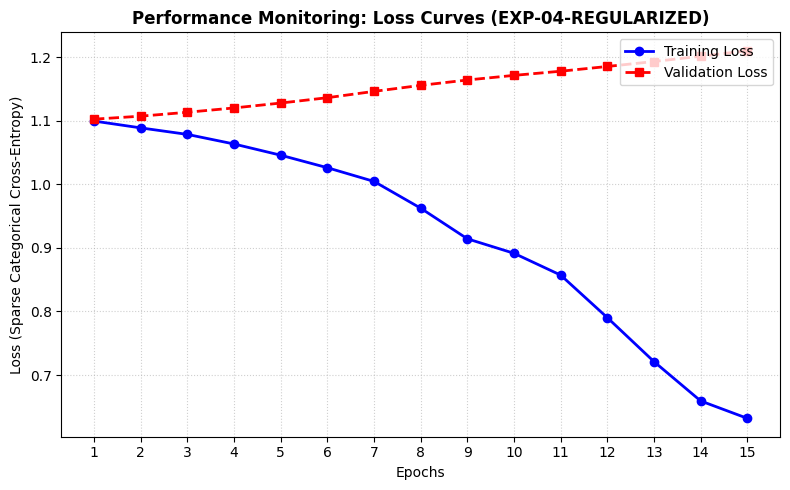

In [ ]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')
plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10); plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range); plt.grid(True, linestyle=':', alpha=0.6); plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CONFIG["run_id"]}.png'), dpi=120)
plt.show()

**Line-by-Line Explanation**
1. `train_losses` / `val_losses` are pulled from the training `history` object.
2. The two `plt.plot` calls draw the training loss (blue) and validation loss (red dashed) against the epoch number.
3. Reading the two curves is the diagnosis: **flat and high** = underfitting; **train drops but val rises** = overfitting; **both fall together** = a good fit.
4. `plt.savefig(...)` stores the chart in the Drive `plots` folder so it can be embedded in the IEEE report.

## CELL 3: Hyperparameter Configuration — EXP-05-TUNED
A balanced, tuned configuration **with early stopping**.

In [ ]:
CONFIG = {
    "run_id": "EXP-05-TUNED",
    "embed_dim": 64,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 16,
    "epochs": 60,
    "optimizer_type": "Adam",
    "dropout_rate": 0.3
}

**Line-by-Line Explanation**
1. `run_id` — the label `EXP-05-TUNED`, used in printouts and the saved plot filename.
2. `embed_dim` = 64 — size of each word vector (**Pillar 1: Architecture**).
3. `hidden_dim` = 128 — neurons in the hidden Dense layer (**Pillar 1: Architecture**).
4. `learning_rate` = 0.005 — how big each weight update is (**Pillar 2: Optimization**).
5. `batch_size` = 16 / `epochs` = 60 — batch size and number of passes (**Pillar 2**).
6. `dropout_rate` = 0.3 — fraction of neurons switched off during training (**Pillar 3: Regularization**).

## CELL 4: Keras Sequential Architecture — EXP-05-TUNED

In [ ]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,), dtype='int32'))
model.add(Embedding(input_dim=len(vocab), output_dim=CONFIG["embed_dim"], mask_zero=True))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 20, 64)         │         9,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,243 (71.26 KB)

 Trainable params: 18,243 (71.26 KB)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**
1. `Sequential()` — a straight stack of layers.
2. `Input(shape=(MAX_LEN,))` — fixes the input to `MAX_LEN` token IDs (keeps Keras 3 happy and lets `summary()` work).
3. `Embedding(...)` — turns each token ID into a trainable `embed_dim`-length vector; `mask_zero=True` ignores padding.
4. `GlobalAveragePooling1D()` — averages the word vectors into one sentence vector (this + Embedding = feature extraction).
5. `Dense(hidden_dim, 'relu')` — the hidden classification layer.
6. `Dropout(dropout_rate)` — regularization to fight overfitting.
7. `Dense(num_classes, 'softmax')` — outputs a probability for each class.

## CELL 5: Optimizer & Compilation — EXP-05-TUNED

In [ ]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

**Line-by-Line Explanation**
1. The `if/else` picks the optimizer engine — **Adam** (adaptive) or **SGD** — using the configured learning rate.
2. `model.compile(...)` attaches the **loss function** (`sparse_categorical_crossentropy`, for integer labels), the optimizer, and the metric (accuracy). This prepares the model for training.

## CELL 6: The Operational Loop (Fit & Evaluate) — EXP-05-TUNED

In [ ]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

# Final validation metrics for the experiment log
val_preds = np.argmax(model.predict(X_val), axis=1)
val_f1 = f1_score(y_val, val_preds, average='weighted', zero_division=0)
val_acc = accuracy_score(y_val, val_preds)
val_loss = history.history['val_loss'][-1]
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | "
      f"Dropout: {CONFIG['dropout_rate']} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Save this run into the results list for the final summary table
results = [r for r in results if r['Run ID'] != CONFIG['run_id']]   # avoid duplicates on re-run
results.append({
    'Run ID': CONFIG['run_id'], 'Dataset': os.path.basename(CSV_FILEPATH),
    'Embed': CONFIG['embed_dim'], 'Hidden': CONFIG['hidden_dim'], 'LR': CONFIG['learning_rate'],
    'Dropout': CONFIG['dropout_rate'], 'Batch': CONFIG['batch_size'],
    'Epochs Run': len(history.history['loss']), 'Val Size': int(len(y_val)),
    'Train Loss': round(float(history.history['loss'][-1]), 4),
    'Val Loss': round(float(val_loss), 4),
    'Train Acc': round(float(history.history['accuracy'][-1]), 4),
    'Val Acc': round(float(val_acc), 4), 'Val F1': round(float(val_f1), 4),
})

--- Starting Training Run: EXP-05-TUNED ---
Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2000 - loss: 1.1011 - val_accuracy: 0.5000 - val_loss: 1.0928
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9000 - loss: 1.0851 - val_accuracy: 0.0000e+00 - val_loss: 1.0981
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.9000 - loss: 1.0698 - val_accuracy: 0.0000e+00 - val_loss: 1.1027
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9000 - loss: 1.0475 - val_accuracy: 0.0000e+00 - val_loss: 1.1068
Epoch 5/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.8000 - loss: 1.0186 - val_accuracy: 0.0000e+00 - val_loss: 1.1116
Epoch 6/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.9772 - val_accuracy: 0.0000e+00 - val_loss: 1.1165
Epoch 7/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.9450 - val_accuracy: 0.0000e+00 - val_loss: 1.1205
Epoch 8/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

=== EXP LOG ENTRY ===
ID: EXP-05-TUNED | LR: 0.005 | Hidden: 128 | Dropout: 0.3 | Val Loss: 1.1259 | Val Acc: 0.5000 | Val F1: 0.6667


**Line-by-Line Explanation**
0b. `EarlyStopping(...)` stops training when validation loss stops improving and restores the best weights.
1. `model.fit(...)` is the training loop — for every batch of every epoch Keras runs the **Forward Pass → Loss Calculation → Backward Pass (backpropagation) → Weight Update**.
2. `validation_data=(X_val, y_val)` evaluates the model on unseen data after each epoch so we can watch for overfitting.
3. `np.argmax(model.predict(X_val), axis=1)` turns the softmax probabilities into predicted class numbers.
4. `val_f1`, `val_acc`, `val_loss` are the final numbers we record for this run in the experiment log.

## CELL 7: Generate Loss Curves Chart — EXP-05-TUNED

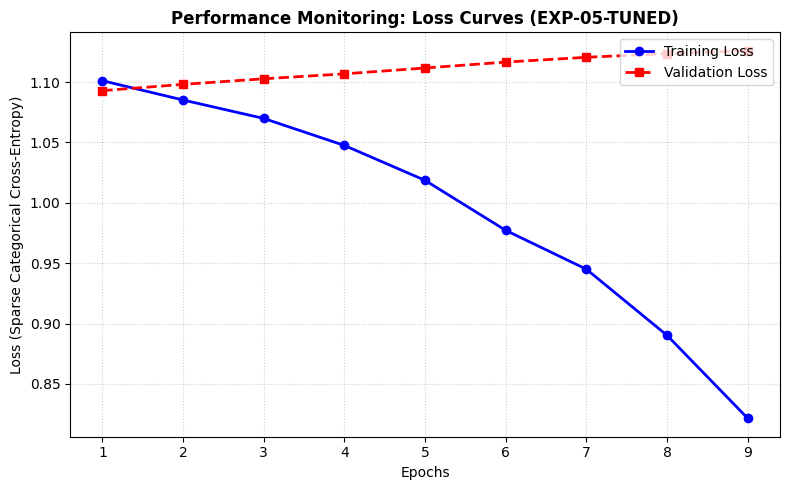

In [ ]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')
plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10); plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range); plt.grid(True, linestyle=':', alpha=0.6); plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CONFIG["run_id"]}.png'), dpi=120)
plt.show()

**Line-by-Line Explanation**
1. `train_losses` / `val_losses` are pulled from the training `history` object.
2. The two `plt.plot` calls draw the training loss (blue) and validation loss (red dashed) against the epoch number.
3. Reading the two curves is the diagnosis: **flat and high** = underfitting; **train drops but val rises** = overfitting; **both fall together** = a good fit.
4. `plt.savefig(...)` stores the chart in the Drive `plots` folder so it can be embedded in the IEEE report.

## CELL 2B: Reload Data for the Free-Form Runs (`PT-P1_food.csv`)
EXP-05A and EXP-05B use our own food-delivery dataset, so we reload it here (this overwrites `X_train`, `X_val`,
etc. with the food data). Run the cells above first so the `sample_dataset` experiments finish before this.

In [ ]:
CSV_FILEPATH = find_csv('PT-P1_food.csv')
assert CSV_FILEPATH, 'PT-P1_food.csv not found in Drive.'
df = pd.read_csv(CSV_FILEPATH)
LABEL_COL = 'category' if 'category' in df.columns else 'label'

classes = sorted(df[LABEL_COL].unique())
label_to_id = {c: i for i, c in enumerate(classes)}
vocab = build_vocab(df['text'].tolist(), MAX_VOCAB_SIZE)
X_data = np.array([text_to_sequence(t, vocab, MAX_LEN) for t in df['text']])
y_data = np.array([label_to_id[l] for l in df[LABEL_COL]])
num_classes = len(classes)

X_train, X_temp, y_train, y_temp = safe_split(X_data, y_data, 0.30)
X_val,  X_test, y_val,  y_test  = safe_split(X_temp, y_temp, 0.50)
print('FOOD classes:', classes, '| vocab:', len(vocab))
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test.shape)

FOOD classes: ['Negative_Complaint', 'Positive_Praise', 'Urgent_Support'] | vocab: 266
Train: (147, 20) | Val: (31, 20) | Test: (32, 20)


**Line-by-Line Explanation**
1. `CSV_FILEPATH = find_csv('PT-P1_food.csv')` locates our food-delivery dataset and loads it.
2. It reuses the same `build_vocab`, `text_to_sequence`, and `safe_split` helpers defined in CELL 2, rebuilding the vocabulary and re-encoding for the new domain.
3. After this cell, `X_train` / `X_val` / `X_test` now hold the **food** data, so the EXP-05A / EXP-05B runs below train on it.

## CELL 3: Hyperparameter Configuration — EXP-05A
Free-form optimization on `PT-P1_food.csv`: larger embedding, more epochs, early stopping.

In [ ]:
CONFIG = {
    "run_id": "EXP-05A",
    "embed_dim": 64,
    "hidden_dim": 96,
    "learning_rate": 0.003,
    "batch_size": 16,
    "epochs": 60,
    "optimizer_type": "Adam",
    "dropout_rate": 0.3
}

**Line-by-Line Explanation**
1. `run_id` — the label `EXP-05A`, used in printouts and the saved plot filename.
2. `embed_dim` = 64 — size of each word vector (**Pillar 1: Architecture**).
3. `hidden_dim` = 96 — neurons in the hidden Dense layer (**Pillar 1: Architecture**).
4. `learning_rate` = 0.003 — how big each weight update is (**Pillar 2: Optimization**).
5. `batch_size` = 16 / `epochs` = 60 — batch size and number of passes (**Pillar 2**).
6. `dropout_rate` = 0.3 — fraction of neurons switched off during training (**Pillar 3: Regularization**).

## CELL 4: Keras Sequential Architecture — EXP-05A

In [ ]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,), dtype='int32'))
model.add(Embedding(input_dim=len(vocab), output_dim=CONFIG["embed_dim"], mask_zero=True))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 20, 64)         │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 96)             │         6,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,555 (92.01 KB)

 Trainable params: 23,555 (92.01 KB)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**
1. `Sequential()` — a straight stack of layers.
2. `Input(shape=(MAX_LEN,))` — fixes the input to `MAX_LEN` token IDs (keeps Keras 3 happy and lets `summary()` work).
3. `Embedding(...)` — turns each token ID into a trainable `embed_dim`-length vector; `mask_zero=True` ignores padding.
4. `GlobalAveragePooling1D()` — averages the word vectors into one sentence vector (this + Embedding = feature extraction).
5. `Dense(hidden_dim, 'relu')` — the hidden classification layer.
6. `Dropout(dropout_rate)` — regularization to fight overfitting.
7. `Dense(num_classes, 'softmax')` — outputs a probability for each class.

## CELL 5: Optimizer & Compilation — EXP-05A

In [ ]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

**Line-by-Line Explanation**
1. The `if/else` picks the optimizer engine — **Adam** (adaptive) or **SGD** — using the configured learning rate.
2. `model.compile(...)` attaches the **loss function** (`sparse_categorical_crossentropy`, for integer labels), the optimizer, and the metric (accuracy). This prepares the model for training.

## CELL 6: The Operational Loop (Fit & Evaluate) — EXP-05A

In [ ]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

# Final validation metrics for the experiment log
val_preds = np.argmax(model.predict(X_val), axis=1)
val_f1 = f1_score(y_val, val_preds, average='weighted', zero_division=0)
val_acc = accuracy_score(y_val, val_preds)
val_loss = history.history['val_loss'][-1]
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | "
      f"Dropout: {CONFIG['dropout_rate']} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Save this run into the results list for the final summary table
results = [r for r in results if r['Run ID'] != CONFIG['run_id']]   # avoid duplicates on re-run
results.append({
    'Run ID': CONFIG['run_id'], 'Dataset': os.path.basename(CSV_FILEPATH),
    'Embed': CONFIG['embed_dim'], 'Hidden': CONFIG['hidden_dim'], 'LR': CONFIG['learning_rate'],
    'Dropout': CONFIG['dropout_rate'], 'Batch': CONFIG['batch_size'],
    'Epochs Run': len(history.history['loss']), 'Val Size': int(len(y_val)),
    'Train Loss': round(float(history.history['loss'][-1]), 4),
    'Val Loss': round(float(val_loss), 4),
    'Train Acc': round(float(history.history['accuracy'][-1]), 4),
    'Val Acc': round(float(val_acc), 4), 'Val F1': round(float(val_f1), 4),
})

--- Starting Training Run: EXP-05A ---
Epoch 1/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6667 - loss: 1.0686 - val_accuracy: 0.9677 - val_loss: 1.0033
Epoch 2/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9728 - loss: 0.8910 - val_accuracy: 0.9677 - val_loss: 0.7513
Epoch 3/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9728 - loss: 0.5482 - val_accuracy: 0.9355 - val_loss: 0.4103
Epoch 4/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.2190 - val_accuracy: 0.9677 - val_loss: 0.1860
Epoch 5/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0605 - val_accuracy: 0.9677 - val_loss: 0.0980
Epoch 6/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0198 - val_accuracy: 0.9677 - val_loss: 0.0743
Epoch 7/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 0.9677 - val_loss: 0.0659
Epoch 8/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

=== EXP LOG ENTRY ===
ID: EXP-05A | LR: 0.003 | Hidden: 96 | Dropout: 0.3 | Val Loss: 0.0657 | Val Acc: 0.9677 | Val F1: 0.9676


**Line-by-Line Explanation**
0b. `EarlyStopping(...)` stops training when validation loss stops improving and restores the best weights.
1. `model.fit(...)` is the training loop — for every batch of every epoch Keras runs the **Forward Pass → Loss Calculation → Backward Pass (backpropagation) → Weight Update**.
2. `validation_data=(X_val, y_val)` evaluates the model on unseen data after each epoch so we can watch for overfitting.
3. `np.argmax(model.predict(X_val), axis=1)` turns the softmax probabilities into predicted class numbers.
4. `val_f1`, `val_acc`, `val_loss` are the final numbers we record for this run in the experiment log.

## CELL 7: Generate Loss Curves Chart — EXP-05A

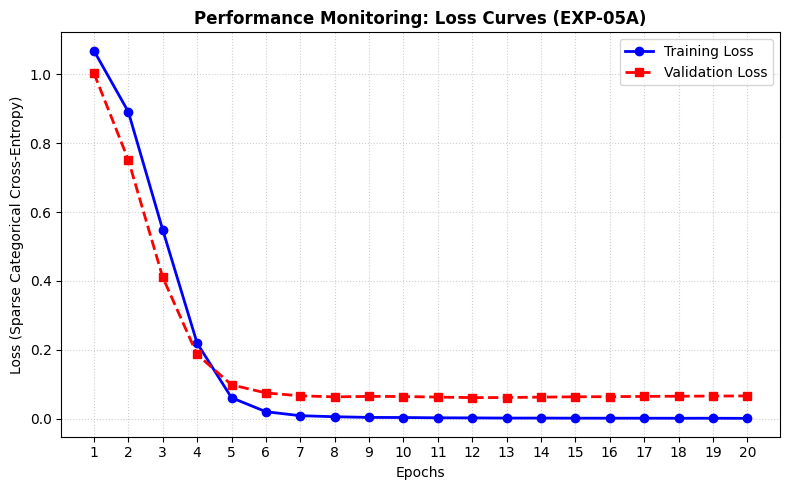

In [ ]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')
plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10); plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range); plt.grid(True, linestyle=':', alpha=0.6); plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CONFIG["run_id"]}.png'), dpi=120)
plt.show()

**Line-by-Line Explanation**
1. `train_losses` / `val_losses` are pulled from the training `history` object.
2. The two `plt.plot` calls draw the training loss (blue) and validation loss (red dashed) against the epoch number.
3. Reading the two curves is the diagnosis: **flat and high** = underfitting; **train drops but val rises** = overfitting; **both fall together** = a good fit.
4. `plt.savefig(...)` stores the chart in the Drive `plots` folder so it can be embedded in the IEEE report.

## CELL 3: Hyperparameter Configuration — EXP-05B
Free-form optimization on `PT-P1_food.csv`: smaller batch, deeper training, stronger dropout.

In [ ]:
CONFIG = {
    "run_id": "EXP-05B",
    "embed_dim": 48,
    "hidden_dim": 128,
    "learning_rate": 0.005,
    "batch_size": 8,
    "epochs": 80,
    "optimizer_type": "Adam",
    "dropout_rate": 0.35
}

**Line-by-Line Explanation**
1. `run_id` — the label `EXP-05B`, used in printouts and the saved plot filename.
2. `embed_dim` = 48 — size of each word vector (**Pillar 1: Architecture**).
3. `hidden_dim` = 128 — neurons in the hidden Dense layer (**Pillar 1: Architecture**).
4. `learning_rate` = 0.005 — how big each weight update is (**Pillar 2: Optimization**).
5. `batch_size` = 8 / `epochs` = 80 — batch size and number of passes (**Pillar 2**).
6. `dropout_rate` = 0.35 — fraction of neurons switched off during training (**Pillar 3: Regularization**).

## CELL 4: Keras Sequential Architecture — EXP-05B

In [ ]:
model = Sequential()
model.add(Input(shape=(MAX_LEN,), dtype='int32'))
model.add(Embedding(input_dim=len(vocab), output_dim=CONFIG["embed_dim"], mask_zero=True))
model.add(GlobalAveragePooling1D())
model.add(Dense(CONFIG["hidden_dim"], activation='relu'))
model.add(Dropout(CONFIG["dropout_rate"]))
model.add(Dense(num_classes, activation='softmax'))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 20, 48)         │        12,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 48)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,427 (75.89 KB)

 Trainable params: 19,427 (75.89 KB)

 Non-trainable params: 0 (0.00 B)

**Line-by-Line Explanation**
1. `Sequential()` — a straight stack of layers.
2. `Input(shape=(MAX_LEN,))` — fixes the input to `MAX_LEN` token IDs (keeps Keras 3 happy and lets `summary()` work).
3. `Embedding(...)` — turns each token ID into a trainable `embed_dim`-length vector; `mask_zero=True` ignores padding.
4. `GlobalAveragePooling1D()` — averages the word vectors into one sentence vector (this + Embedding = feature extraction).
5. `Dense(hidden_dim, 'relu')` — the hidden classification layer.
6. `Dropout(dropout_rate)` — regularization to fight overfitting.
7. `Dense(num_classes, 'softmax')` — outputs a probability for each class.

## CELL 5: Optimizer & Compilation — EXP-05B

In [ ]:
if CONFIG["optimizer_type"] == "Adam":
    opt = Adam(learning_rate=CONFIG["learning_rate"])
else:
    opt = SGD(learning_rate=CONFIG["learning_rate"])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

**Line-by-Line Explanation**
1. The `if/else` picks the optimizer engine — **Adam** (adaptive) or **SGD** — using the configured learning rate.
2. `model.compile(...)` attaches the **loss function** (`sparse_categorical_crossentropy`, for integer labels), the optimizer, and the metric (accuracy). This prepares the model for training.

## CELL 6: The Operational Loop (Fit & Evaluate) — EXP-05B

In [ ]:
print(f"--- Starting Training Run: {CONFIG['run_id']} ---")
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=[early_stop],
    verbose=1
)

# Final validation metrics for the experiment log
val_preds = np.argmax(model.predict(X_val), axis=1)
val_f1 = f1_score(y_val, val_preds, average='weighted', zero_division=0)
val_acc = accuracy_score(y_val, val_preds)
val_loss = history.history['val_loss'][-1]
print(f"\n=== EXP LOG ENTRY ===")
print(f"ID: {CONFIG['run_id']} | LR: {CONFIG['learning_rate']} | Hidden: {CONFIG['hidden_dim']} | "
      f"Dropout: {CONFIG['dropout_rate']} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

# Save this run into the results list for the final summary table
results = [r for r in results if r['Run ID'] != CONFIG['run_id']]   # avoid duplicates on re-run
results.append({
    'Run ID': CONFIG['run_id'], 'Dataset': os.path.basename(CSV_FILEPATH),
    'Embed': CONFIG['embed_dim'], 'Hidden': CONFIG['hidden_dim'], 'LR': CONFIG['learning_rate'],
    'Dropout': CONFIG['dropout_rate'], 'Batch': CONFIG['batch_size'],
    'Epochs Run': len(history.history['loss']), 'Val Size': int(len(y_val)),
    'Train Loss': round(float(history.history['loss'][-1]), 4),
    'Val Loss': round(float(val_loss), 4),
    'Train Acc': round(float(history.history['accuracy'][-1]), 4),
    'Val Acc': round(float(val_acc), 4), 'Val F1': round(float(val_f1), 4),
})

--- Starting Training Run: EXP-05B ---
Epoch 1/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6803 - loss: 1.0001 - val_accuracy: 0.9355 - val_loss: 0.7251
Epoch 2/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.3524 - val_accuracy: 0.9677 - val_loss: 0.1399
Epoch 3/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0234 - val_accuracy: 0.9677 - val_loss: 0.0810
Epoch 4/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9677 - val_loss: 0.0779
Epoch 5/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.9677 - val_loss: 0.0792
Epoch 6/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9677 - val_loss: 0.0845
Epoch 7/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 6.6567e-04 - val_accuracy: 0.9677 - val_loss: 0.0861
Epoch 8/80
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - los

**Line-by-Line Explanation**
0b. `EarlyStopping(...)` stops training when validation loss stops improving and restores the best weights.
1. `model.fit(...)` is the training loop — for every batch of every epoch Keras runs the **Forward Pass → Loss Calculation → Backward Pass (backpropagation) → Weight Update**.
2. `validation_data=(X_val, y_val)` evaluates the model on unseen data after each epoch so we can watch for overfitting.
3. `np.argmax(model.predict(X_val), axis=1)` turns the softmax probabilities into predicted class numbers.
4. `val_f1`, `val_acc`, `val_loss` are the final numbers we record for this run in the experiment log.

## CELL 7: Generate Loss Curves Chart — EXP-05B

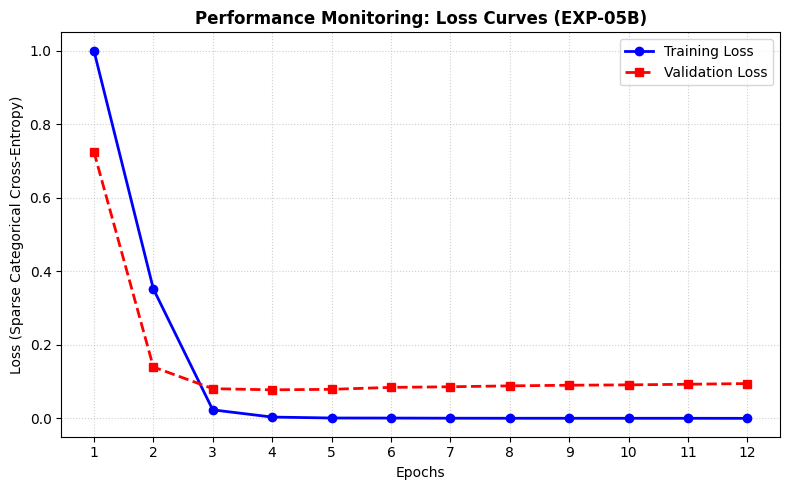

In [ ]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(epochs_range, val_losses, label='Validation Loss', color='red', linewidth=2, linestyle='--', marker='s')
plt.title(f'Performance Monitoring: Loss Curves ({CONFIG["run_id"]})', fontsize=12, fontweight='bold')
plt.xlabel('Epochs', fontsize=10); plt.ylabel('Loss (Sparse Categorical Cross-Entropy)', fontsize=10)
plt.xticks(epochs_range); plt.grid(True, linestyle=':', alpha=0.6); plt.legend(loc='upper right'); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'{CONFIG["run_id"]}.png'), dpi=120)
plt.show()

**Line-by-Line Explanation**
1. `train_losses` / `val_losses` are pulled from the training `history` object.
2. The two `plt.plot` calls draw the training loss (blue) and validation loss (red dashed) against the epoch number.
3. Reading the two curves is the diagnosis: **flat and high** = underfitting; **train drops but val rises** = overfitting; **both fall together** = a good fit.
4. `plt.savefig(...)` stores the chart in the Drive `plots` folder so it can be embedded in the IEEE report.

## CELL 8: Experiment Summary Table and Export
Every run above appended its metrics to the `results` list. This final cell turns that list into one table so all
seven experiments can be compared side by side, marks the **champion** (highest validation F1), and saves the table
to Excel in your Drive folder — this is the experiment log required by the exercise.

In [ ]:
summary = pd.DataFrame(results)

# A champion must be chosen on a validation set large enough to be statistically meaningful.
# The 15-row sample_dataset leaves only ~2 validation samples, so its accuracy can only be
# 0%, 50% or 100% - a run can score "100%" by pure chance while its loss sits at the
# ln(3)=1.0986 chance level (see EXP-02). Those runs are therefore not eligible.
MIN_VAL = 10
eligible = summary[summary['Val Size'] >= MIN_VAL]
if len(eligible) == 0:
    eligible = summary
best = eligible.sort_values(['Val F1', 'Val Loss'], ascending=[False, True]).index[0]
summary['Champion'] = ['<-- CHAMPION' if i == best else '' for i in summary.index]
print(f'Runs eligible for champion (Val Size >= {MIN_VAL}):', list(eligible['Run ID']))

out_path = os.path.join(DRIVE, 'Sagarino_FFBP_Training_Log.xlsx')
summary.to_excel(out_path, index=False)
print('Saved:', out_path)
print('Champion:', summary.loc[best, 'Run ID'],
      '| Val Acc', summary.loc[best, 'Val Acc'], '| Val F1', summary.loc[best, 'Val F1'])
summary

Runs eligible for champion (Val Size >= 10): ['EXP-05A', 'EXP-05B']
Saved: /content/drive/MyDrive/NN Training/plots/Sagarino_FFBP_Training_Log.xlsx
Champion: EXP-05A | Val Acc 0.9677 | Val F1 0.9676


,Run ID,Dataset,Embed,Hidden,LR,Dropout,Batch,Epochs Run,Val Size,Train Loss,Val Loss,Train Acc,Val Acc,Val F1,Champion
0,EXP-01-KERAS-BASELINE,sample_dataset.csv,32,64,0.0050,0.10,32,15,2,0.5933,1.2963,1.0,0.0000,0.0000,
1,EXP-02-UNDERFIT,sample_dataset.csv,32,16,0.0001,0.00,32,15,2,1.0907,1.0950,0.7,1.0000,1.0000,
2,EXP-03-OVERFIT,sample_dataset.csv,32,256,0.0500,0.00,32,15,2,0.0000,15.2350,1.0,0.0000,0.0000,
3,EXP-04-REGULARIZED,sample_dataset.csv,32,128,0.0050,0.40,32,15,2,0.6319,1.2101,1.0,0.0000,0.0000,
4,EXP-05-TUNED,sample_dataset.csv,64,128,0.0050,0.30,16,9,2,0.8216,1.1259,1.0,0.5000,0.6667,
5,EXP-05A,PT-P1_food.csv,64,96,0.0030,0.30,16,20,31,0.0005,0.0657,1.0,0.9677,0.9676,<-- CHAMPION
6,EXP-05B,PT-P1_food.csv,48,128,0.0050,0.35,8,12,31,0.0003,0.0949,1.0,0.9677,0.9676,


**Line-by-Line Explanation**
1. `pd.DataFrame(results)` converts the collected rows into a readable table — one line per experiment.
2. Champion selection is **filtered by validation-set size**. The 15-row `sample_dataset` leaves only about two validation samples, so its accuracy can only be 0%, 50% or 100% — EXP-02 scored a misleading "100%" purely by chance while its loss (1.0950) sat at the ln(3)=1.0986 chance level, proving it learned nothing. Requiring at least 10 validation samples excludes those unreliable runs, so the champion is chosen from the food-dataset runs, ranked by validation F1 and then by lowest validation loss.
3. `summary.to_excel(...)` writes the whole log to Drive so it can be submitted and used in the IEEE report.
4. Displaying `summary` at the end prints every experiment's hyperparameters and final metrics in one place, so there is no need to scroll back through the individual runs.